In [1]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from urllib.parse import urlparse

from sklearn.base import clone

from sklearn.model_selection import (
    train_test_split,
    StratifiedGroupKFold
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

RANDOM_STATE = 42

In [2]:
RAW_DATA_PATH = "../data/raw/PhiUSIIL_Phishing_URL_Dataset.csv"

FEATURE_DATA_PATH = (
    "../data/processed/"
    "deployment_url_features.csv"
)

raw_df = pd.read_csv(
    RAW_DATA_PATH
)

feature_df = pd.read_csv(
    FEATURE_DATA_PATH
)

print(
    "Raw dataset:",
    raw_df.shape
)

print(
    "Feature dataset:",
    feature_df.shape
)

Raw dataset: (235795, 56)
Feature dataset: (235795, 23)


In [3]:
assert len(raw_df) == len(feature_df), (
    "Raw and feature datasets have different row counts."
)

assert np.array_equal(
    raw_df["label"].values,
    feature_df["label"].values
), "Raw and engineered labels are not aligned."

print(
    "Dataset alignment: PASSED"
)

Dataset alignment: PASSED


In [4]:
model_df = feature_df.copy()

model_df.insert(
    0,
    "URL",
    raw_df["URL"].astype(str).values
)

print(
    "Before URL deduplication:",
    model_df.shape
)

model_df = (
    model_df
    .drop_duplicates(
        subset=["URL"],
        keep="first"
    )
    .reset_index(drop=True)
)

print(
    "After URL deduplication:",
    model_df.shape
)

Before URL deduplication: (235795, 24)
After URL deduplication: (235370, 24)


In [5]:
model_df["is_phishing"] = (
    1 - model_df["label"]
)

print(
    model_df[
        ["label", "is_phishing"]
    ]
    .drop_duplicates()
    .sort_values("label")
)

    label  is_phishing
11      0            1
0       1            0


In [6]:
FEATURE_COLUMNS = [
    column
    for column in feature_df.columns
    if column != "label"
]

print(
    "Number of predictors:",
    len(FEATURE_COLUMNS)
)

print(FEATURE_COLUMNS)

Number of predictors: 22
['url_length', 'domain_length', 'path_length', 'query_length', 'dot_count', 'hyphen_count', 'underscore_count', 'slash_count', 'question_count', 'equal_count', 'ampersand_count', 'at_count', 'percent_count', 'digit_count', 'letter_count', 'digit_ratio', 'letter_ratio', 'is_https', 'is_domain_ip', 'subdomain_count', 'suspicious_word_count', 'url_entropy']


In [7]:
X = model_df[
    FEATURE_COLUMNS
].copy()

y = model_df[
    "is_phishing"
].copy()


X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)


print(
    "Train:",
    X_train.shape
)

print(
    "Validation:",
    X_val.shape
)

print(
    "Test:",
    X_test.shape
)

print(
    "\nTEST SET REMAINS LOCKED."
)

Train: (164759, 22)
Validation: (35305, 22)
Test: (35306, 22)

TEST SET REMAINS LOCKED.


In [8]:
logistic_model = joblib.load(
    "../models/baseline_logistic.joblib"
)

random_forest_model = joblib.load(
    "../models/baseline_random_forest.joblib"
)

hist_model = joblib.load(
    "../models/baseline_hist_gradient_boosting.joblib"
)

scaler = joblib.load(
    "../models/baseline_scaler.joblib"
)

print(
    "Baseline models loaded successfully."
)

Baseline models loaded successfully.


In [9]:
print(
    "Logistic features:",
    logistic_model.n_features_in_
)

print(
    "Random Forest features:",
    random_forest_model.n_features_in_
)

print(
    "HistGradientBoosting features:",
    hist_model.n_features_in_
)

Logistic features: 22
Random Forest features: 22
HistGradientBoosting features: 22


In [10]:
X_train_scaled = scaler.transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

In [11]:
def calculate_metrics(
    y_true,
    y_pred,
    y_prob
):
    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "F2": fbeta_score(
            y_true,
            y_pred,
            beta=2,
            zero_division=0
        ),

        "ROC_AUC": roc_auc_score(
            y_true,
            y_prob
        ),

        "PR_AUC": average_precision_score(
            y_true,
            y_prob
        )
    }

In [12]:
log_train_pred = logistic_model.predict(
    X_train_scaled
)

log_train_prob = logistic_model.predict_proba(
    X_train_scaled
)[:, 1]

log_val_pred = logistic_model.predict(
    X_val_scaled
)

log_val_prob = logistic_model.predict_proba(
    X_val_scaled
)[:, 1]

In [13]:
rf_train_pred = random_forest_model.predict(
    X_train
)

rf_train_prob = random_forest_model.predict_proba(
    X_train
)[:, 1]

rf_val_pred = random_forest_model.predict(
    X_val
)

rf_val_prob = random_forest_model.predict_proba(
    X_val
)[:, 1]

In [14]:
hist_train_pred = hist_model.predict(
    X_train
)

hist_train_prob = hist_model.predict_proba(
    X_train
)[:, 1]

hist_val_pred = hist_model.predict(
    X_val
)

hist_val_prob = hist_model.predict_proba(
    X_val
)[:, 1]

In [15]:
overfit_rows = []

models_for_check = {
    "Logistic Regression": (
        log_train_pred,
        log_train_prob,
        log_val_pred,
        log_val_prob
    ),

    "Random Forest": (
        rf_train_pred,
        rf_train_prob,
        rf_val_pred,
        rf_val_prob
    ),

    "HistGradientBoosting": (
        hist_train_pred,
        hist_train_prob,
        hist_val_pred,
        hist_val_prob
    )
}


for model_name, values in models_for_check.items():

    (
        train_pred,
        train_prob,
        val_pred,
        val_prob
    ) = values

    train_metrics = calculate_metrics(
        y_train,
        train_pred,
        train_prob
    )

    val_metrics = calculate_metrics(
        y_val,
        val_pred,
        val_prob
    )

    overfit_rows.append({
        "Model": model_name,

        "Train_F1":
            train_metrics["F1"],

        "Validation_F1":
            val_metrics["F1"],

        "F1_Gap":
            train_metrics["F1"]
            - val_metrics["F1"],

        "Train_Recall":
            train_metrics["Recall"],

        "Validation_Recall":
            val_metrics["Recall"],

        "Recall_Gap":
            train_metrics["Recall"]
            - val_metrics["Recall"],

        "Train_ROC_AUC":
            train_metrics["ROC_AUC"],

        "Validation_ROC_AUC":
            val_metrics["ROC_AUC"]
    })


overfit_df = pd.DataFrame(
    overfit_rows
)

overfit_df

,Model,Train_F1,Validation_F1,F1_Gap,Train_Recall,Validation_Recall,Recall_Gap,Train_ROC_AUC,Validation_ROC_AUC
0,Logistic Regression,0.991990,0.991847,0.000142,0.984694,0.984348,0.000346,0.995793,0.996090
1,Random Forest,0.996901,0.993482,0.003419,0.994315,0.990715,0.003600,0.999541,0.996419
2,HistGradientBoosting,0.995619,0.994470,0.001149,0.991558,0.989919,0.001639,0.998589,0.997678


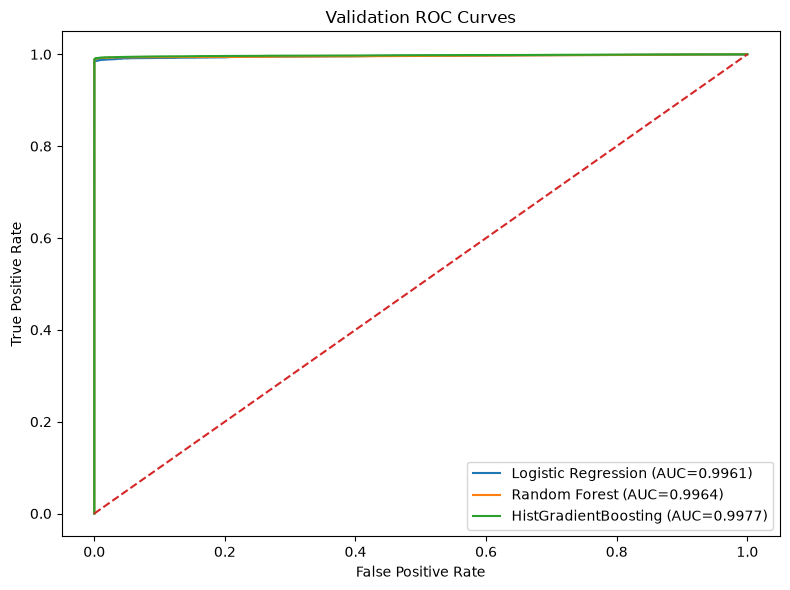

In [16]:
plt.figure(
    figsize=(8, 6)
)

model_probabilities = {
    "Logistic Regression":
        log_val_prob,

    "Random Forest":
        rf_val_prob,

    "HistGradientBoosting":
        hist_val_prob
}


for model_name, probabilities in (
    model_probabilities.items()
):

    fpr, tpr, _ = roc_curve(
        y_val,
        probabilities
    )

    auc_score = roc_auc_score(
        y_val,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=(
            f"{model_name} "
            f"(AUC={auc_score:.4f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Validation ROC Curves"
)

plt.legend()

plt.tight_layout()

plt.show()

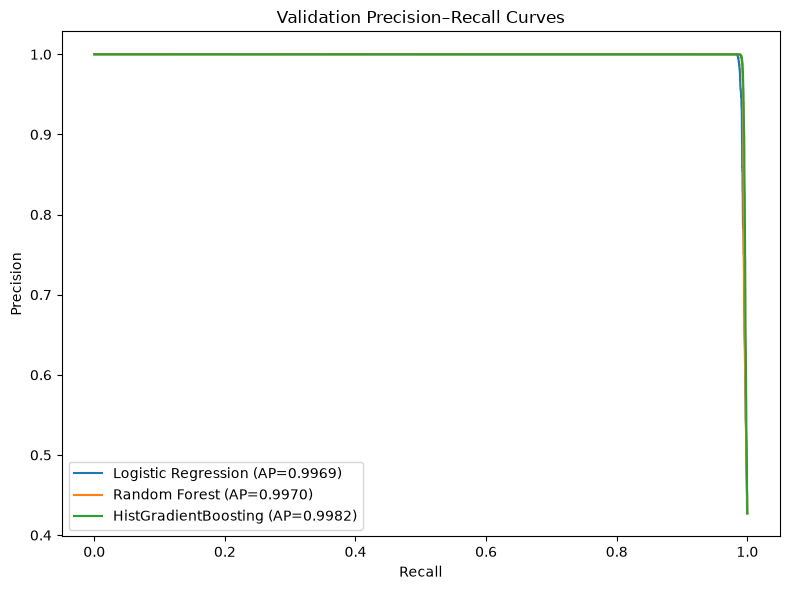

In [17]:
plt.figure(
    figsize=(8, 6)
)


for model_name, probabilities in (
    model_probabilities.items()
):

    precision, recall, _ = (
        precision_recall_curve(
            y_val,
            probabilities
        )
    )

    pr_auc = average_precision_score(
        y_val,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        label=(
            f"{model_name} "
            f"(AP={pr_auc:.4f})"
        )
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Validation Precision–Recall Curves"
)

plt.legend()

plt.tight_layout()

plt.show()

In [18]:
def threshold_analysis(
    y_true,
    probabilities
):

    rows = []

    thresholds = np.arange(
        0.05,
        0.96,
        0.01
    )

    for threshold in thresholds:

        predictions = (
            probabilities
            >= threshold
        ).astype(int)

        cm = confusion_matrix(
            y_true,
            predictions
        )

        tn, fp, fn, tp = (
            cm.ravel()
        )

        rows.append({
            "Threshold":
                threshold,

            "Precision":
                precision_score(
                    y_true,
                    predictions,
                    zero_division=0
                ),

            "Recall":
                recall_score(
                    y_true,
                    predictions,
                    zero_division=0
                ),

            "F1":
                f1_score(
                    y_true,
                    predictions,
                    zero_division=0
                ),

            "F2":
                fbeta_score(
                    y_true,
                    predictions,
                    beta=2,
                    zero_division=0
                ),

            "False_Positives":
                fp,

            "False_Negatives":
                fn
        })

    return pd.DataFrame(
        rows
    )

In [19]:
log_threshold_df = threshold_analysis(
    y_val,
    log_val_prob
)

rf_threshold_df = threshold_analysis(
    y_val,
    rf_val_prob
)

hist_threshold_df = threshold_analysis(
    y_val,
    hist_val_prob
)

In [21]:
def best_f2_threshold(
    threshold_df
):

    best_row = threshold_df.loc[
        threshold_df["F2"].idxmax()
    ]

    return best_row

In [22]:
print(
    "LOGISTIC REGRESSION"
)

print(
    best_f2_threshold(
        log_threshold_df
    )
)


print(
    "\nRANDOM FOREST"
)

print(
    best_f2_threshold(
        rf_threshold_df
    )
)


print(
    "\nHIST GRADIENT BOOSTING"
)

print(
    best_f2_threshold(
        hist_threshold_df
    )
)

LOGISTIC REGRESSION
Threshold            0.170000
Precision            0.994916
Recall               0.986338
F1                   0.990608
F2                   0.988041
False_Positives     76.000000
False_Negatives    206.000000
Name: 12, dtype: float64

RANDOM FOREST
Threshold            0.380000
Precision            0.995139
Recall               0.991047
F1                   0.993088
F2                   0.991862
False_Positives     73.000000
False_Negatives    135.000000
Name: 33, dtype: float64

HIST GRADIENT BOOSTING
Threshold            0.140000
Precision            0.994745
Recall               0.991776
F1                   0.993258
F2                   0.992368
False_Positives     79.000000
False_Negatives    124.000000
Name: 9, dtype: float64


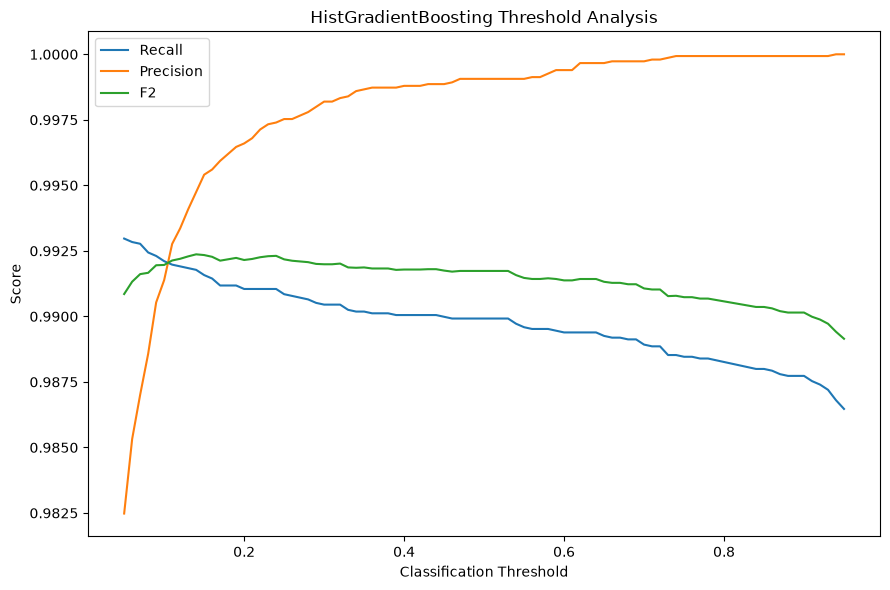

In [23]:
plt.figure(
    figsize=(9, 6)
)

plt.plot(
    hist_threshold_df[
        "Threshold"
    ],
    hist_threshold_df[
        "Recall"
    ],
    label="Recall"
)

plt.plot(
    hist_threshold_df[
        "Threshold"
    ],
    hist_threshold_df[
        "Precision"
    ],
    label="Precision"
)

plt.plot(
    hist_threshold_df[
        "Threshold"
    ],
    hist_threshold_df[
        "F2"
    ],
    label="F2"
)

plt.xlabel(
    "Classification Threshold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "HistGradientBoosting Threshold Analysis"
)

plt.legend()

plt.tight_layout()

plt.show()

In [24]:
def build_error_dataframe(
    X_subset,
    y_true,
    probabilities,
    threshold=0.50
):

    predictions = (
        probabilities
        >= threshold
    ).astype(int)

    error_df = pd.DataFrame({
        "URL":
            model_df.loc[
                X_subset.index,
                "URL"
            ],

        "Actual":
            y_true,

        "Predicted":
            predictions,

        "Phishing_Probability":
            probabilities
    })

    return error_df

In [25]:
rf_errors = build_error_dataframe(
    X_val,
    y_val,
    rf_val_prob,
    threshold=0.50
)

In [26]:
rf_false_negatives = rf_errors[
    (rf_errors["Actual"] == 1)
    &
    (rf_errors["Predicted"] == 0)
]

print(
    "RF False Negatives:",
    len(rf_false_negatives)
)

rf_false_negatives.head(20)

RF False Negatives: 140


,URL,Actual,Predicted,Phishing_Probability
117548,https://www.v2deniz.net,1,0,0.083293
98005,https://i.violationspage.validationspege.worke...,1,0,0.260000
99036,https://www.insideoutconstructionva.com,1,0,0.000000
130478,https://www.at0.srev.workers.dev,1,0,0.240000
133927,https://login.internettdbs.com,1,0,0.002461
185631,https://officialcolorfulnetwork.posisipo.repl.co,1,0,0.305000
39106,https://php-web-server.pldeplos.repl.co,1,0,0.170000
126129,https://www.top.guiadeoportunidades.com.br,1,0,0.145000
69003,https://www.foilloo.xyz,1,0,0.001812
220356,https://www.steamcomunilty.com,1,0,0.010493


In [27]:
rf_false_positives = rf_errors[
    (rf_errors["Actual"] == 0)
    &
    (rf_errors["Predicted"] == 1)
]

print(
    "RF False Positives:",
    len(rf_false_positives)
)

rf_false_positives.head(20)

RF False Positives: 56


,URL,Actual,Predicted,Phishing_Probability
58527,https://www.showroomworkstation.org.uk,0,1,0.710000
131402,https://www.innerchild-sexaddiction.com,0,1,0.620000
203641,https://www.stjohnswoodchurch.org.uk,0,1,0.722917
22594,https://www.direct-democracy-navigator.org,0,1,0.535000
119750,https://www.equifaxsecurity2017.com,0,1,0.580000
2605,https://www.feestzaal-geraardsbergen.be,0,1,0.847357
86823,https://www.hull-humber-chamber.co.uk,0,1,0.715000
79600,https://www.nationaal-parkdegrootepeel.nl,0,1,0.773750
102989,https://www.t3-framework.org,0,1,0.505000
10508,https://www.c250.columbia.edu,0,1,0.525000


In [28]:
def extract_hostname(url):

    url = str(url).strip()

    if not url.startswith(
        ("http://", "https://")
    ):
        url = (
            "http://"
            + url
        )

    parsed = urlparse(
        url
    )

    return (
        parsed.hostname
        or ""
    ).lower()

In [29]:
model_df[
    "hostname_group"
] = (
    model_df["URL"]
    .apply(
        extract_hostname
    )
)

print(
    "Unique hostnames:",
    model_df[
        "hostname_group"
    ].nunique()
)

Unique hostnames: 220077


In [30]:
development_indices = (
    X_train.index
    .union(
        X_val.index
    )
)


development_df = (
    model_df.loc[
        development_indices
    ]
    .copy()
)


X_dev = development_df[
    FEATURE_COLUMNS
]

y_dev = development_df[
    "is_phishing"
]

groups_dev = development_df[
    "hostname_group"
]


print(
    "Development rows:",
    len(development_df)
)

print(
    "Test rows still untouched:",
    len(X_test)
)

Development rows: 200064
Test rows still untouched: 35306


In [31]:
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


group_train_positions, group_val_positions = (
    next(
        sgkf.split(
            X_dev,
            y_dev,
            groups_dev
        )
    )
)


X_group_train = X_dev.iloc[
    group_train_positions
]

y_group_train = y_dev.iloc[
    group_train_positions
]


X_group_val = X_dev.iloc[
    group_val_positions
]

y_group_val = y_dev.iloc[
    group_val_positions
]

In [32]:
group_train_hosts = set(
    groups_dev.iloc[
        group_train_positions
    ]
)

group_val_hosts = set(
    groups_dev.iloc[
        group_val_positions
    ]
)


hostname_overlap = (
    group_train_hosts
    &
    group_val_hosts
)


print(
    "Group training rows:",
    len(X_group_train)
)

print(
    "Group validation rows:",
    len(X_group_val)
)

print(
    "Hostname overlap:",
    len(hostname_overlap)
)

Group training rows: 160050
Group validation rows: 40014
Hostname overlap: 0


In [33]:
print(
    "Group train distribution:"
)

print(
    y_group_train
    .value_counts(
        normalize=True
    )
)


print(
    "\nGroup validation distribution:"
)

print(
    y_group_val
    .value_counts(
        normalize=True
    )
)

Group train distribution:
is_phishing
0    0.572927
1    0.427073
Name: proportion, dtype: float64

Group validation distribution:
is_phishing
0    0.572924
1    0.427076
Name: proportion, dtype: float64


In [34]:
print(
    "Group train distribution:"
)

print(
    y_group_train
    .value_counts(
        normalize=True
    )
)


print(
    "\nGroup validation distribution:"
)

print(
    y_group_val
    .value_counts(
        normalize=True
    )
)

Group train distribution:
is_phishing
0    0.572927
1    0.427073
Name: proportion, dtype: float64

Group validation distribution:
is_phishing
0    0.572924
1    0.427076
Name: proportion, dtype: float64


In [35]:
group_scaler = StandardScaler()

X_group_train_scaled = (
    group_scaler.fit_transform(
        X_group_train
    )
)

X_group_val_scaled = (
    group_scaler.transform(
        X_group_val
    )
)


group_logistic = clone(
    logistic_model
)

group_logistic.fit(
    X_group_train_scaled,
    y_group_train
)


group_log_prob = (
    group_logistic
    .predict_proba(
        X_group_val_scaled
    )[:, 1]
)

group_log_pred = (
    group_log_prob
    >= 0.50
).astype(int)

In [36]:
group_rf = clone(
    random_forest_model
)

group_rf.fit(
    X_group_train,
    y_group_train
)


group_rf_prob = (
    group_rf.predict_proba(
        X_group_val
    )[:, 1]
)

group_rf_pred = (
    group_rf_prob
    >= 0.50
).astype(int)

In [37]:
group_hist = clone(
    hist_model
)

group_hist.fit(
    X_group_train,
    y_group_train
)


group_hist_prob = (
    group_hist.predict_proba(
        X_group_val
    )[:, 1]
)

group_hist_pred = (
    group_hist_prob
    >= 0.50
).astype(int)

In [38]:
group_results = []


for (
    model_name,
    predictions,
    probabilities
) in [

    (
        "Logistic Regression",
        group_log_pred,
        group_log_prob
    ),

    (
        "Random Forest",
        group_rf_pred,
        group_rf_prob
    ),

    (
        "HistGradientBoosting",
        group_hist_pred,
        group_hist_prob
    )
]:

    metrics = calculate_metrics(
        y_group_val,
        predictions,
        probabilities
    )

    cm = confusion_matrix(
        y_group_val,
        predictions
    )

    tn, fp, fn, tp = (
        cm.ravel()
    )

    group_results.append({
        "Model":
            model_name,

        **metrics,

        "False_Positives":
            fp,

        "False_Negatives":
            fn
    })


group_results_df = (
    pd.DataFrame(
        group_results
    )
    .sort_values(
        "F2",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


group_results_df

,Model,Accuracy,Precision,Recall,F1,F2,ROC_AUC,PR_AUC,False_Positives,False_Negatives
0,HistGradientBoosting,0.995926,0.998704,0.991749,0.995214,0.993132,0.997909,0.998406,22,141
1,Random Forest,0.994977,0.996181,0.992042,0.994107,0.992867,0.996918,0.997433,65,136
2,Logistic Regression,0.993827,0.999348,0.986190,0.992725,0.988794,0.996698,0.997450,11,236


In [39]:
standard_results = []


for (
    model_name,
    predictions,
    probabilities
) in [

    (
        "Logistic Regression",
        log_val_pred,
        log_val_prob
    ),

    (
        "Random Forest",
        rf_val_pred,
        rf_val_prob
    ),

    (
        "HistGradientBoosting",
        hist_val_pred,
        hist_val_prob
    )
]:

    metrics = calculate_metrics(
        y_val,
        predictions,
        probabilities
    )

    standard_results.append({
        "Model":
            model_name,

        "Standard_F1":
            metrics["F1"],

        "Standard_F2":
            metrics["F2"],

        "Standard_Recall":
            metrics["Recall"],

        "Standard_ROC_AUC":
            metrics["ROC_AUC"]
    })


standard_results_df = pd.DataFrame(
    standard_results
)


comparison_df = (
    standard_results_df
    .merge(
        group_results_df[
            [
                "Model",
                "F1",
                "F2",
                "Recall",
                "ROC_AUC"
            ]
        ],
        on="Model"
    )
)


comparison_df = comparison_df.rename(
    columns={
        "F1":
            "Hostname_F1",

        "F2":
            "Hostname_F2",

        "Recall":
            "Hostname_Recall",

        "ROC_AUC":
            "Hostname_ROC_AUC"
    }
)


comparison_df[
    "F1_Drop"
] = (
    comparison_df[
        "Standard_F1"
    ]
    -
    comparison_df[
        "Hostname_F1"
    ]
)


comparison_df

,Model,Standard_F1,Standard_F2,Standard_Recall,Standard_ROC_AUC,Hostname_F1,Hostname_F2,Hostname_Recall,Hostname_ROC_AUC,F1_Drop
0,Logistic Regression,0.991847,0.987334,0.984348,0.996090,0.992725,0.988794,0.986190,0.996698,-0.000878
1,Random Forest,0.993482,0.991820,0.990715,0.996419,0.994107,0.992867,0.992042,0.996918,-0.000624
2,HistGradientBoosting,0.994470,0.991734,0.989919,0.997678,0.995214,0.993132,0.991749,0.997909,-0.000744


In [40]:
HOSTNAME_CHECK_THRESHOLD = 0.14

group_hist_threshold_pred = (
    group_hist_prob >= HOSTNAME_CHECK_THRESHOLD
).astype(int)

group_hist_threshold_metrics = calculate_metrics(
    y_group_val,
    group_hist_threshold_pred,
    group_hist_prob
)

group_hist_threshold_cm = confusion_matrix(
    y_group_val,
    group_hist_threshold_pred
)

print("=" * 60)
print("HISTGRADIENTBOOSTING — HOSTNAME HOLDOUT")
print("THRESHOLD:", HOSTNAME_CHECK_THRESHOLD)
print("=" * 60)

for metric, value in group_hist_threshold_metrics.items():
    print(f"{metric:12}: {value:.6f}")

print("\nConfusion Matrix:")
print(group_hist_threshold_cm)

tn_g, fp_g, fn_g, tp_g = (
    group_hist_threshold_cm.ravel()
)

print("\nTrue Negatives :", tn_g)
print("False Positives:", fp_g)
print("False Negatives:", fn_g)
print("True Positives :", tp_g)

HISTGRADIENTBOOSTING — HOSTNAME HOLDOUT
THRESHOLD: 0.14
Accuracy    : 0.994502
Precision   : 0.993794
Recall      : 0.993329
F1          : 0.993562
F2          : 0.993422
ROC_AUC     : 0.997909
PR_AUC      : 0.998406

Confusion Matrix:
[[22819   106]
 [  114 16975]]

True Negatives : 22819
False Positives: 106
False Negatives: 114
True Positives : 16975


In [41]:
group_hist_default_pred = (
    group_hist_prob >= 0.50
).astype(int)

default_cm = confusion_matrix(
    y_group_val,
    group_hist_default_pred
)

tuned_cm = confusion_matrix(
    y_group_val,
    group_hist_threshold_pred
)

_, default_fp, default_fn, _ = default_cm.ravel()
_, tuned_fp, tuned_fn, _ = tuned_cm.ravel()

print("DEFAULT THRESHOLD 0.50")
print("False Positives:", default_fp)
print("False Negatives:", default_fn)

print("\nTUNED THRESHOLD 0.14")
print("False Positives:", tuned_fp)
print("False Negatives:", tuned_fn)

DEFAULT THRESHOLD 0.50
False Positives: 22
False Negatives: 141

TUNED THRESHOLD 0.14
False Positives: 106
False Negatives: 114


In [48]:
FINAL_MODEL_NAME = "HistGradientBoosting"

FINAL_THRESHOLD = 0.14

print("FINAL MODEL LOCKED")
print("Model     :", FINAL_MODEL_NAME)
print("Threshold :", FINAL_THRESHOLD)

FINAL MODEL LOCKED
Model     : HistGradientBoosting
Threshold : 0.14


In [49]:
assert FINAL_MODEL_NAME == "HistGradientBoosting"
assert FINAL_THRESHOLD == 0.14

print("Final configuration verified.")

Final configuration verified.


In [50]:
X_final_train = pd.concat(
    [
        X_train,
        X_val
    ]
)

y_final_train = pd.concat(
    [
        y_train,
        y_val
    ]
)

print(
    "Final training samples:",
    len(X_final_train)
)

print(
    "Final untouched test samples:",
    len(X_test)
)

Final training samples: 200064
Final untouched test samples: 35306


In [51]:
# 6.30 — Train final HistGradientBoosting model

from sklearn.base import clone

assert FINAL_MODEL_NAME == "HistGradientBoosting"
assert FINAL_THRESHOLD == 0.14

# HistGradientBoosting does not require StandardScaler
X_final_train_input = X_final_train
X_test_input = X_test

# Create a fresh copy of the selected baseline model
final_model = clone(hist_model)

# Retrain using Train + Validation
final_model.fit(
    X_final_train_input,
    y_final_train
)

print("Final model trained successfully.")
print("Model     :", FINAL_MODEL_NAME)
print("Threshold :", FINAL_THRESHOLD)
print("Training samples:", len(X_final_train))
print("Test samples    :", len(X_test))

Final model trained successfully.
Model     : HistGradientBoosting
Threshold : 0.14
Training samples: 200064
Test samples    : 35306


In [52]:
# 6.31 — Generate final test predictions

test_probabilities = final_model.predict_proba(
    X_test_input
)[:, 1]

test_predictions = (
    test_probabilities >= FINAL_THRESHOLD
).astype(int)

print("Final test predictions generated.")
print("Samples predicted :", len(test_predictions))
print("Threshold used    :", FINAL_THRESHOLD)

Final test predictions generated.
Samples predicted : 35306
Threshold used    : 0.14


In [53]:
assert len(test_predictions) == len(y_test)
assert len(test_probabilities) == len(y_test)

assert np.all(
    (test_probabilities >= 0)
    &
    (test_probabilities <= 1)
)

print("Prediction validation: PASSED")

Prediction validation: PASSED


In [54]:
final_test_metrics = calculate_metrics(
    y_test,
    test_predictions,
    test_probabilities
)

print("=" * 60)
print("FINAL TEST EVALUATION")
print("=" * 60)

print("Model     :", FINAL_MODEL_NAME)
print("Threshold :", FINAL_THRESHOLD)

print()

for metric, value in final_test_metrics.items():
    print(
        f"{metric:12}: {value:.6f}"
    )

final_cm = confusion_matrix(
    y_test,
    test_predictions
)

print("\nConfusion Matrix:")
print(final_cm)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Legitimate",
            "Phishing"
        ],
        zero_division=0
    )
)

FINAL TEST EVALUATION
Model     : HistGradientBoosting
Threshold : 0.14

Accuracy    : 0.994250
Precision   : 0.993170
Recall      : 0.993368
F1          : 0.993269
F2          : 0.993328
ROC_AUC     : 0.998217
PR_AUC      : 0.998622

Confusion Matrix:
[[20125   103]
 [  100 14978]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     20228
    Phishing       0.99      0.99      0.99     15078

    accuracy                           0.99     35306
   macro avg       0.99      0.99      0.99     35306
weighted avg       0.99      0.99      0.99     35306



In [55]:
tn, fp, fn, tp = final_cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 20125
False Positives: 103
False Negatives: 100
True Positives : 14978


In [56]:
import os
import joblib

os.makedirs(
    "../models",
    exist_ok=True
)

FINAL_MODEL_PATH = (
    "../models/final_phishing_model.joblib"
)

joblib.dump(
    final_model,
    FINAL_MODEL_PATH
)

print(
    "Final model saved:",
    FINAL_MODEL_PATH
)

Final model saved: ../models/final_phishing_model.joblib


In [57]:
if final_scaler is not None:

    FINAL_SCALER_PATH = (
        "../models/final_scaler.joblib"
    )

    joblib.dump(
        final_scaler,
        FINAL_SCALER_PATH
    )

    print(
        "Final scaler saved:",
        FINAL_SCALER_PATH
    )

In [58]:
import json

metadata = {
    "model_name": FINAL_MODEL_NAME,
    "decision_threshold": float(
        FINAL_THRESHOLD
    ),
    "feature_count": len(
        FEATURE_COLUMNS
    ),
    "features": FEATURE_COLUMNS,
    "target_name": "is_phishing",

    "target_mapping": {
        "0": "legitimate",
        "1": "phishing"
    },

    "training_strategy": (
        "Exact URL deduplication; "
        "70/15/15 stratified split; "
        "model and threshold selected using "
        "validation and hostname-disjoint holdout; "
        "final model retrained on train+validation."
    ),

    "test_metrics": {
        key: float(value)
        for key, value
        in final_test_metrics.items()
    }
}

METADATA_PATH = (
    "../data/processed/"
    "final_model_metadata.json"
)

with open(
    METADATA_PATH,
    "w"
) as file:

    json.dump(
        metadata,
        file,
        indent=4
    )

print(
    "Metadata saved:",
    METADATA_PATH
)

Metadata saved: ../data/processed/final_model_metadata.json


In [59]:
final_results_df = pd.DataFrame([
    {
        "Model": FINAL_MODEL_NAME,
        "Threshold": FINAL_THRESHOLD,

        **final_test_metrics,

        "True_Negatives": tn,
        "False_Positives": fp,
        "False_Negatives": fn,
        "True_Positives": tp
    }
])

FINAL_RESULTS_PATH = (
    "../data/processed/"
    "final_test_results.csv"
)

final_results_df.to_csv(
    FINAL_RESULTS_PATH,
    index=False
)

print(
    "Saved:",
    FINAL_RESULTS_PATH
)

final_results_df

Saved: ../data/processed/final_test_results.csv


,Model,Threshold,Accuracy,Precision,Recall,F1,F2,ROC_AUC,PR_AUC,True_Negatives,False_Positives,False_Negatives,True_Positives
0,HistGradientBoosting,0.14,0.99425,0.99317,0.993368,0.993269,0.993328,0.998217,0.998622,20125,103,100,14978


In [60]:
print("=" * 70)
print("PHASE 6 — FINAL MODEL EVALUATION SUMMARY")
print("=" * 70)

print(
    f"Selected model       : "
    f"{FINAL_MODEL_NAME}"
)

print(
    f"Decision threshold   : "
    f"{FINAL_THRESHOLD:.2f}"
)

print(
    f"Predictor features   : "
    f"{len(FEATURE_COLUMNS)}"
)

print(
    f"Final train samples  : "
    f"{len(X_final_train):,}"
)

print(
    f"Final test samples   : "
    f"{len(X_test):,}"
)

print("\nFINAL TEST METRICS")
print("-" * 40)

for metric, value in final_test_metrics.items():

    print(
        f"{metric:12}: "
        f"{value:.6f}"
    )

print("\nCONFUSION MATRIX")
print(final_cm)

print(
    "\nTrue Negatives :",
    tn
)

print(
    "False Positives:",
    fp
)

print(
    "False Negatives:",
    fn
)

print(
    "True Positives :",
    tp
)

print(
    "\nFinal model saved:"
)

print(
    "../models/"
    "final_phishing_model.joblib"
)

PHASE 6 — FINAL MODEL EVALUATION SUMMARY
Selected model       : HistGradientBoosting
Decision threshold   : 0.14
Predictor features   : 22
Final train samples  : 200,064
Final test samples   : 35,306

FINAL TEST METRICS
----------------------------------------
Accuracy    : 0.994250
Precision   : 0.993170
Recall      : 0.993368
F1          : 0.993269
F2          : 0.993328
ROC_AUC     : 0.998217
PR_AUC      : 0.998622

CONFUSION MATRIX
[[20125   103]
 [  100 14978]]

True Negatives : 20125
False Positives: 103
False Negatives: 100
True Positives : 14978

Final model saved:
../models/final_phishing_model.joblib
